# Análisis Exploratorio de Consumo Energético en Brasil

En este proyecto se realizará un análisis exploratorio de un dataset de consumo energético en Brasil con el objetivo de identificar patrones temporales, distribuciones y posibles relaciones entre variables relacionadas al consumo eléctrico.

El análisis incluirá exploración de datos, limpieza, visualización y segmentación por regiones y sectores económicos.

In [55]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Cargamos el archivo
df = pd.read_excel('datos_energia_bra.xlsx')

_Inspección del dataset._

Inspección inicial del dataset para comprender su estructura y observar las primeras filas.

In [22]:
df.head()

,Data,TipoConsumidor,Sistema,UF,Setor Econômico - N1,Setor Econômico - N2,Setor Econômico - N3,Tipo Tensão - N1,Tipo Tensão - N2,Tipo Tensão - N3,Faixa de Consumo N1,Faixa de Consumo N2,Consumidores,Consumo
0,20140101,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
1,20140201,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,8.0
2,20140301,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,9.0
3,20140401,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,10.0
4,20140501,Cativo,Sudeste / Centro-Oeste,RO,Residencial,Convencional (Excepto Baixa Renda),TOTAL,A - Alta Tensão,TOTAL,TOTAL,Alta Tensão,Alta Tensão,1.0,9.0


---
Exploración inicial

In [23]:
df.info()
df.columns

<class 'pandas.DataFrame'>
RangeIndex: 285499 entries, 0 to 285498
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Data                  285499 non-null  int64  
 1   TipoConsumidor        285499 non-null  str    
 2   Sistema               285499 non-null  str    
 3   UF                    285499 non-null  str    
 4   Setor Econômico - N1  285499 non-null  str    
 5   Setor Econômico - N2  285499 non-null  str    
 6   Setor Econômico - N3  285499 non-null  str    
 7   Tipo Tensão - N1      285499 non-null  str    
 8   Tipo Tensão - N2      285499 non-null  str    
 9   Tipo Tensão - N3      285499 non-null  str    
 10  Faixa de Consumo N1   285499 non-null  str    
 11  Faixa de Consumo N2   285499 non-null  str    
 12  Consumidores          281511 non-null  float64
 13  Consumo               275799 non-null  float64
dtypes: float64(2), int64(1), str(11)
memory usage: 30.5 MB


Index(['Data', 'TipoConsumidor', 'Sistema', 'UF', 'Setor Econômico - N1',
       'Setor Econômico - N2', 'Setor Econômico - N3', 'Tipo Tensão - N1',
       'Tipo Tensão - N2', 'Tipo Tensão - N3', 'Faixa de Consumo N1',
       'Faixa de Consumo N2', 'Consumidores', 'Consumo'],
      dtype='str')

In [24]:
df.describe()

,Data,Consumidores,Consumo
count,2.854990e+05,2.815110e+05,2.757990e+05
mean,2.018754e+07,3.572126e+04,1.758421e+04
std,2.862986e+04,2.078181e+05,7.510192e+04
min,2.014010e+07,-5.108800e+04,-2.093080e+05
25%,2.016090e+07,9.000000e+00,1.090000e+02
50%,2.019040e+07,1.320000e+02,1.470000e+03
75%,2.021090e+07,3.222000e+03,9.614000e+03
max,2.023120e+07,6.652168e+06,1.850736e+06


El dataset contiene variables categóricas relacionadas con sectores económicos, sistemas eléctricos y tipos de tensión, además de variables numéricas como cantidad de consumidores y consumo energético.

CONVERTIR FECHA

In [56]:
df["Data"] = pd.to_datetime(
    df["Data"],
    format="%Y%m%d"
)

La columna Data fue convertida al formato datetime para facilitar el análisis temporal y la extracción de componentes como meses y años.

---
LIMPIEZA DE DATOS

In [62]:
df.isnull().sum()

Data                       0
TipoConsumidor             0
Sistema                    0
UF                         0
Setor Econômico - N1       0
Setor Econômico - N2       0
Setor Econômico - N3       0
Tipo Tensão - N1           0
Tipo Tensão - N2           0
Tipo Tensão - N3           0
Faixa de Consumo N1        0
Faixa de Consumo N2        0
Consumidores            3988
Consumo                 9700
dtype: int64

In [63]:
df = df.dropna()

Se eliminaron registros con valores nulos para evitar inconsistencias durante el análisis.

## Análisis temporal del consumo total

Para analizar la evolución general del consumo energético, se agruparon los registros por fecha y se sumó el consumo total de cada período. Esto permite observar el comportamiento global del consumo en Brasil a través del tiempo.

In [86]:
#Ordena los datos por fecha
df = df.sort_values('Data')
#Agrupa por fecha para sumar el consumo total de todo Brasil
df_mensual_total = df.groupby('Data')['Consumo'].sum().reset_index()

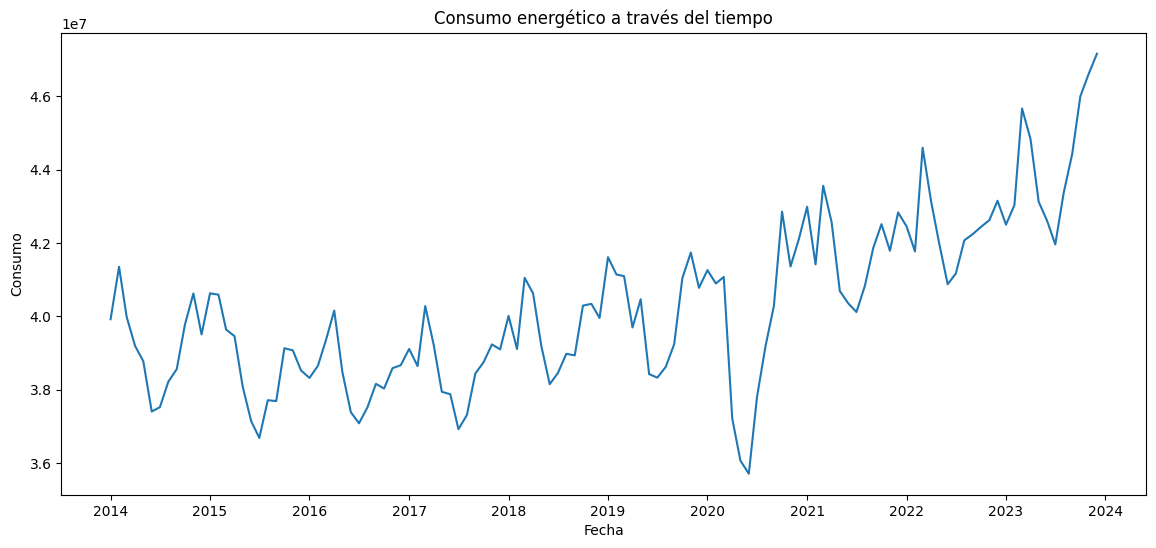

In [87]:
plt.figure(figsize=(14,6))

plt.plot(
    df_mensual_total["Data"],
    df_mensual_total["Consumo"]
)

plt.title("Consumo energético a través del tiempo")

plt.xlabel("Fecha")
plt.ylabel("Consumo")

plt.show()

El gráfico muestra la evolución del consumo energético total a lo largo del tiempo. Se observan variaciones entre períodos, lo que permite identificar posibles picos, caídas o cambios en la demanda energética nacional.

DISTRIBUCIÓN DE CONSUMO.

Para comprender cómo se distribuye el consumo energético total, se construyó un histograma utilizando el consumo agrupado por fecha.

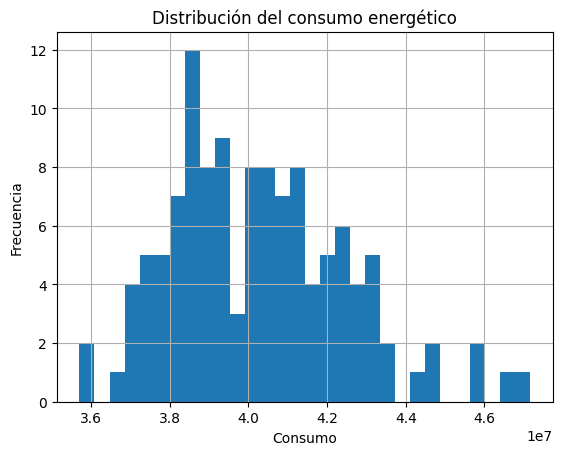

In [89]:
df_mensual_total["Consumo"].hist(
    bins=30
)

plt.title("Distribución del consumo energético")

plt.xlabel("Consumo")
plt.ylabel("Frecuencia")

plt.show()

El histograma muestra una concentración importante de períodos con niveles de consumo similares, aunque también se observan algunos períodos con consumos considerablemente más altos.

DETECCIÓN DE OUTLIERS.

Se utilizó un boxplot para analizar la dispersión del consumo energético total y detectar posibles valores extremos.

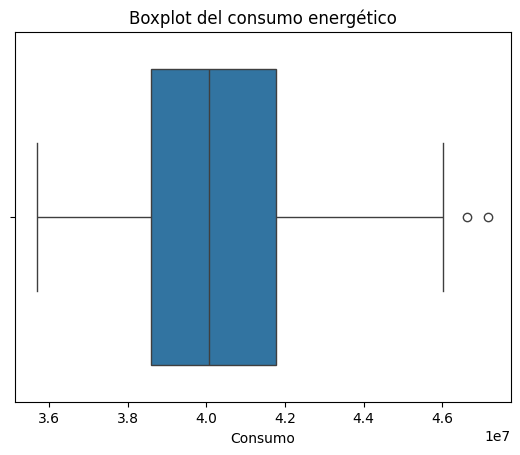

In [90]:
sns.boxplot(
    x=df_mensual_total["Consumo"]
)

plt.title("Boxplot del consumo energético")

plt.show()

El boxplot muestra una distribución relativamente estable del consumo total, aunque se detectan algunos períodos con consumos considerablemente superiores al resto.

---
Columnas auxiliares de tiempo

In [91]:
df["Año"] = df["Data"].dt.year
df["Mes"] = df["Data"].dt.month

Se extrajeron el año y el mes para facilitar el análisis temporal del consumo energético.

---
CONSUMO TOTAL POR AÑO

Para comparar el comportamiento del consumo energético entre distintos años, se agrupó el consumo total anual.

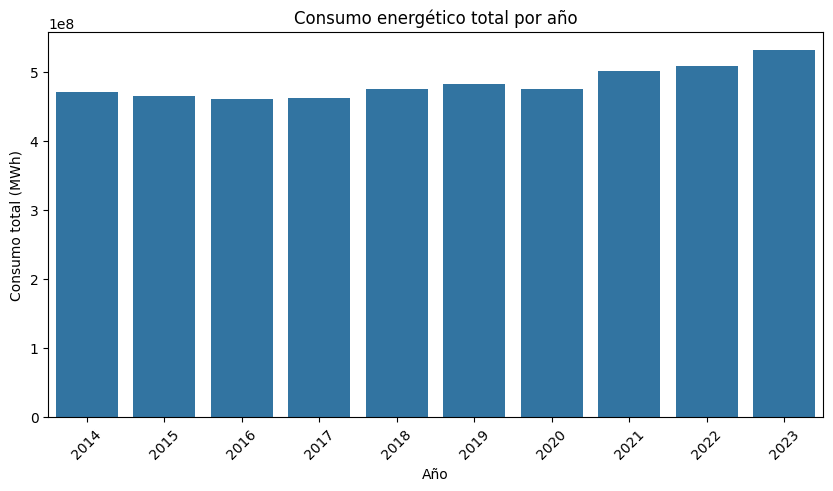

In [92]:
consumo_anual = df.groupby("Año")["Consumo"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=consumo_anual, x="Año", y="Consumo")

plt.title("Consumo energético total por año")
plt.xlabel("Año")
plt.ylabel("Consumo total (MWh)")
plt.xticks(rotation=45)

plt.show()

El análisis anual muestra un comportamiento relativamente estable del consumo energético, aunque se observa una ligera tendencia creciente en los últimos años.

---
Consumo promedio por mes

Para identificar posibles patrones estacionales, se calculó el consumo promedio por mes.

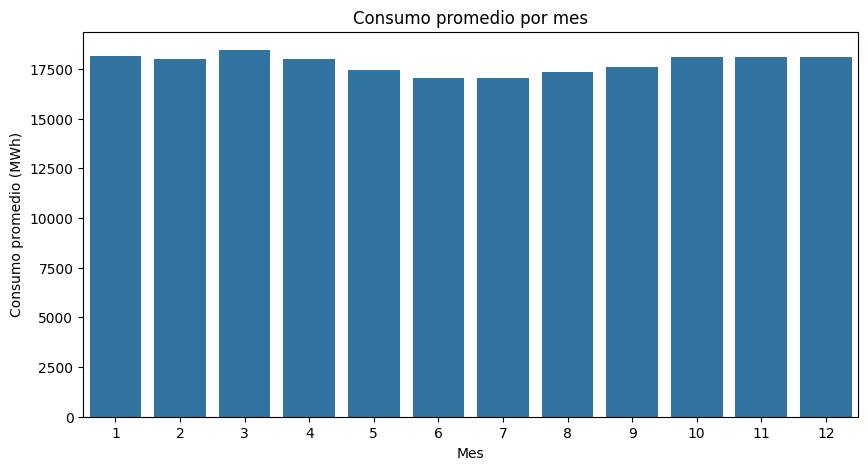

In [76]:
consumo_mensual = df.groupby("Mes")["Consumo"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=consumo_mensual, x="Mes", y="Consumo")

plt.title("Consumo promedio por mes")
plt.xlabel("Mes")
plt.ylabel("Consumo promedio (MWh)")

plt.show()

El análisis mensual muestra pequeñas variaciones entre meses, observándose una leve reducción del consumo entre los meses 4 y 9, aunque el comportamiento general permanece relativamente estable.

HEATMAP

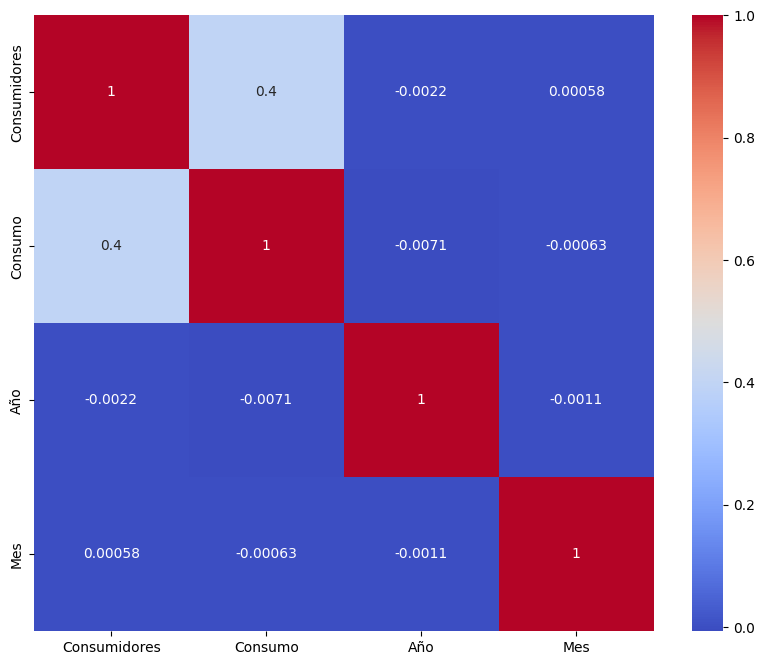

In [80]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()

CONSUMO POR SISTEMA

Para comparar el consumo energético entre distintos sistemas eléctricos, se calculó el consumo total agrupado por sistema.

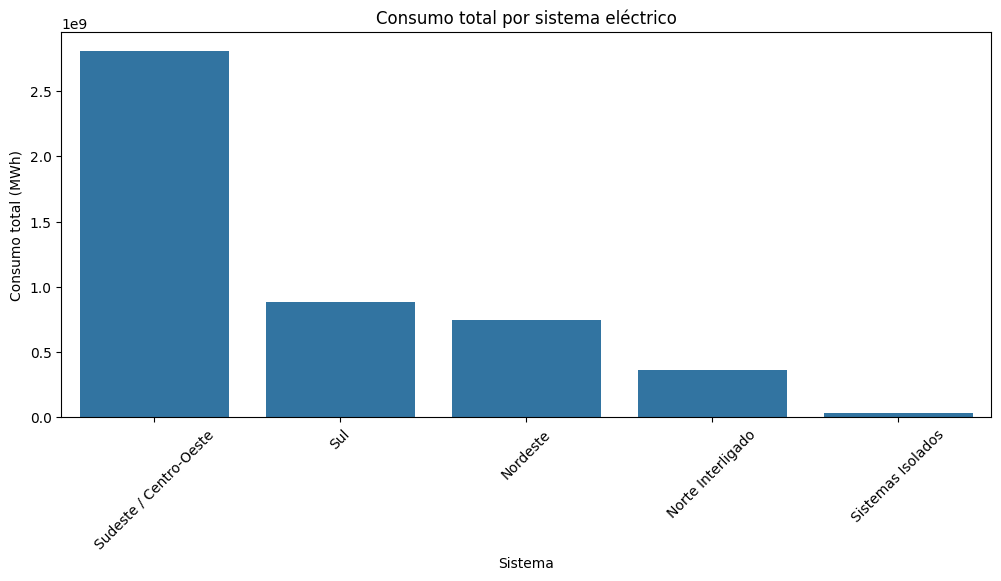

In [77]:
consumo_sistema = (
    df.groupby("Sistema")["Consumo"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12,5))
sns.barplot(data=consumo_sistema, x="Sistema", y="Consumo")

plt.title("Consumo total por sistema eléctrico")
plt.xlabel("Sistema")
plt.ylabel("Consumo total (MWh)")
plt.xticks(rotation=45)

plt.show()

El consumo total no se distribuye de forma uniforme entre sistemas eléctricos, lo que sugiere diferencias regionales relevantes en la demanda energética.

CONSUMO POR SECTOR ECONOMICO

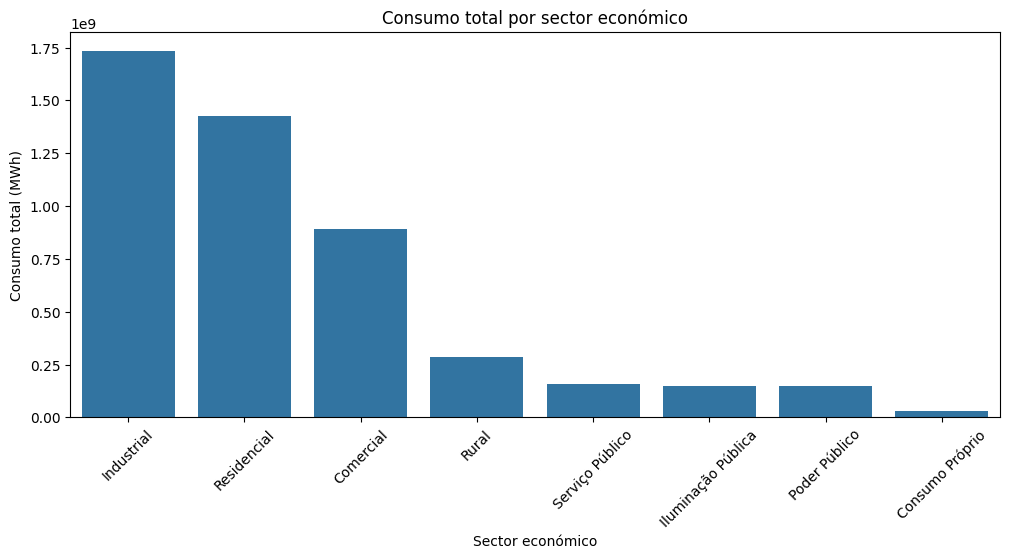

In [78]:
consumo_sector = (
    df.groupby("Setor Econômico - N1")["Consumo"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12,5))
sns.barplot(data=consumo_sector, x="Setor Econômico - N1", y="Consumo")

plt.title("Consumo total por sector económico")
plt.xlabel("Sector económico")
plt.ylabel("Consumo total (MWh)")
plt.xticks(rotation=45)

plt.show()

Relación consumidores vs consumo

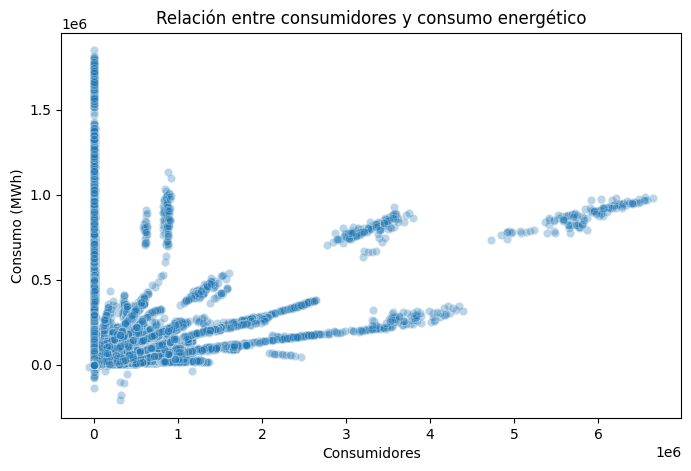

In [79]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Consumidores",
    y="Consumo",
    alpha=0.3
)

plt.title("Relación entre consumidores y consumo energético")
plt.xlabel("Consumidores")
plt.ylabel("Consumo (MWh)")

plt.show()

Se analiza si una mayor cantidad de consumidores está asociada con mayores niveles de consumo energético.

## Hallazgos principales

- El consumo energético total presenta variaciones relevantes a través del tiempo.
- Algunos años muestran niveles de consumo superiores al resto.
- Se observaron diferencias importantes de consumo entre sistemas eléctricos.
- El consumo también varía según el sector económico.
- La cantidad de consumidores presenta una relación positiva con el consumo energético.

## Conclusión

El análisis exploratorio permitió identificar patrones temporales, diferencias regionales y variaciones por sector económico en el consumo energético de Brasil. Estos resultados sugieren que el consumo eléctrico no depende únicamente del tiempo, sino también del sistema eléctrico, el sector económico y la cantidad de consumidores registrados.